# Linux Kernel — Wizualizacje sieci

## F. "Pokaż mi tę sieć" — wizualizacje strukturalne

Sieć ma 466k węzłów, więc rysowanie całości nie ma sensu. Robimy zamiast tego:
1. **Ego-graf hubów** — najważniejsza funkcja + jej sąsiedztwo
2. **k-core extraction** — najgłębszy rdzeń jako podsieć
3. **Meta-graf subsystemów** — circular layout, grubość krawędzi ∝ liczba wywołań
4. **2D embedding** — projekcja spektralna (laplacian eigenmaps) węzłów
5. **Sankey-flow** — przepływy między subsystemami

Każda figura jest gotowa do druku 300 DPI.

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.collections import LineCollection
import seaborn as sns
import networkit as nk
import networkx as nx
from collections import Counter, defaultdict

DATA = Path("../data/out")
OUT = Path("../figures/poster")
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "font.size": 13,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
sns.set_palette("colorblind")

WONG = [
    "#0072B2",
    "#E69F00",
    "#009E73",
    "#CC79A7",
    "#F0E442",
    "#56B4E9",
    "#D55E00",
    "#999999",
]

print("Wczytuję dane...")
metrics = pd.read_csv(DATA / "node_metrics.csv")
edges_raw = pd.read_csv(DATA / "edges.csv")
N = len(metrics)
print(f"Węzłów: {N:,}, krawędzi: {len(edges_raw):,}")

id_to_idx = {fid: i for i, fid in enumerate(metrics["id"].values)}

edges_idx = edges_raw.copy()
edges_idx["src_idx"] = edges_idx["source"].map(id_to_idx)
edges_idx["tgt_idx"] = edges_idx["target"].map(id_to_idx)

before = len(edges_idx)
edges_idx = edges_idx.dropna(subset=["src_idx", "tgt_idx"])
edges_idx["src_idx"] = edges_idx["src_idx"].astype(int)
edges_idx["tgt_idx"] = edges_idx["tgt_idx"].astype(int)
print(f"Krawędzi po mapowaniu: {len(edges_idx):,} (usunięto {before - len(edges_idx)})")

G = nk.graph.Graph(N, directed=True)
for s_idx, t_idx in zip(edges_idx["src_idx"].values, edges_idx["tgt_idx"].values):
    G.addEdge(int(s_idx), int(t_idx))
print(f"NetworKit graph: {G.numberOfNodes():,} węzłów, {G.numberOfEdges():,} krawędzi")


def name_of(idx):
    """Helper: idx -> func_name"""
    return metrics.iloc[idx]["func_name"]


def subsys_of(idx):
    return metrics.iloc[idx]["subsystem"]

Wczytuję dane...
Węzłów: 467,924, krawędzi: 4,440,158
Krawędzi po mapowaniu: 4,440,158 (usunięto 0)
NetworKit graph: 467,924 węzłów, 4,440,158 krawędzi


## F1. Ego-graf najważniejszego hubu

Ego-graf węzła v = sam v + wszyscy sąsiedzi (in i out) + krawędzie między nimi.
To pokazuje **jak wygląda lokalne sąsiedztwo huba** — czy to "gwiazda" czy gęsta klika?

In [2]:
top_hub_idx = int(metrics["pagerank"].idxmax())
hub_name = name_of(top_hub_idx)
hub_sub = subsys_of(top_hub_idx)
print(f"Top hub: {hub_name} (subsystem: {hub_sub})")
print(f"  in-degree:  {metrics.iloc[top_hub_idx]['in_degree']:,}")
print(f"  out-degree: {metrics.iloc[top_hub_idx]['out_degree']:,}")
print(f"  PageRank:   {metrics.iloc[top_hub_idx]['pagerank']:.5f}")

in_neighbors = list(G.iterInNeighbors(top_hub_idx))
out_neighbors = list(G.iterNeighbors(top_hub_idx))
print(f"\nLiczba in-sąsiadów:  {len(in_neighbors):,}")
print(f"Liczba out-sąsiadów: {len(out_neighbors):,}")

MAX_NEIGHBORS = 60  # max 60 sąsiadów po każdej stronie żeby było czytelnie


def top_k_by_pagerank(node_indices, k):
    if len(node_indices) <= k:
        return node_indices
    pr = metrics.iloc[node_indices]["pagerank"].values
    top = np.argpartition(-pr, k)[:k]
    return [node_indices[i] for i in top]


in_show = top_k_by_pagerank(in_neighbors, MAX_NEIGHBORS)
out_show = top_k_by_pagerank(out_neighbors, MAX_NEIGHBORS)
ego_set = set([top_hub_idx]) | set(in_show) | set(out_show)
print(f"Ego-graf po próbkowaniu: {len(ego_set)} węzłów")

Top hub: _text (subsystem: external)
  in-degree:  29.0
  out-degree: 0.0
  PageRank:   0.07578

Liczba in-sąsiadów:  29
Liczba out-sąsiadów: 0
Ego-graf po próbkowaniu: 30 węzłów


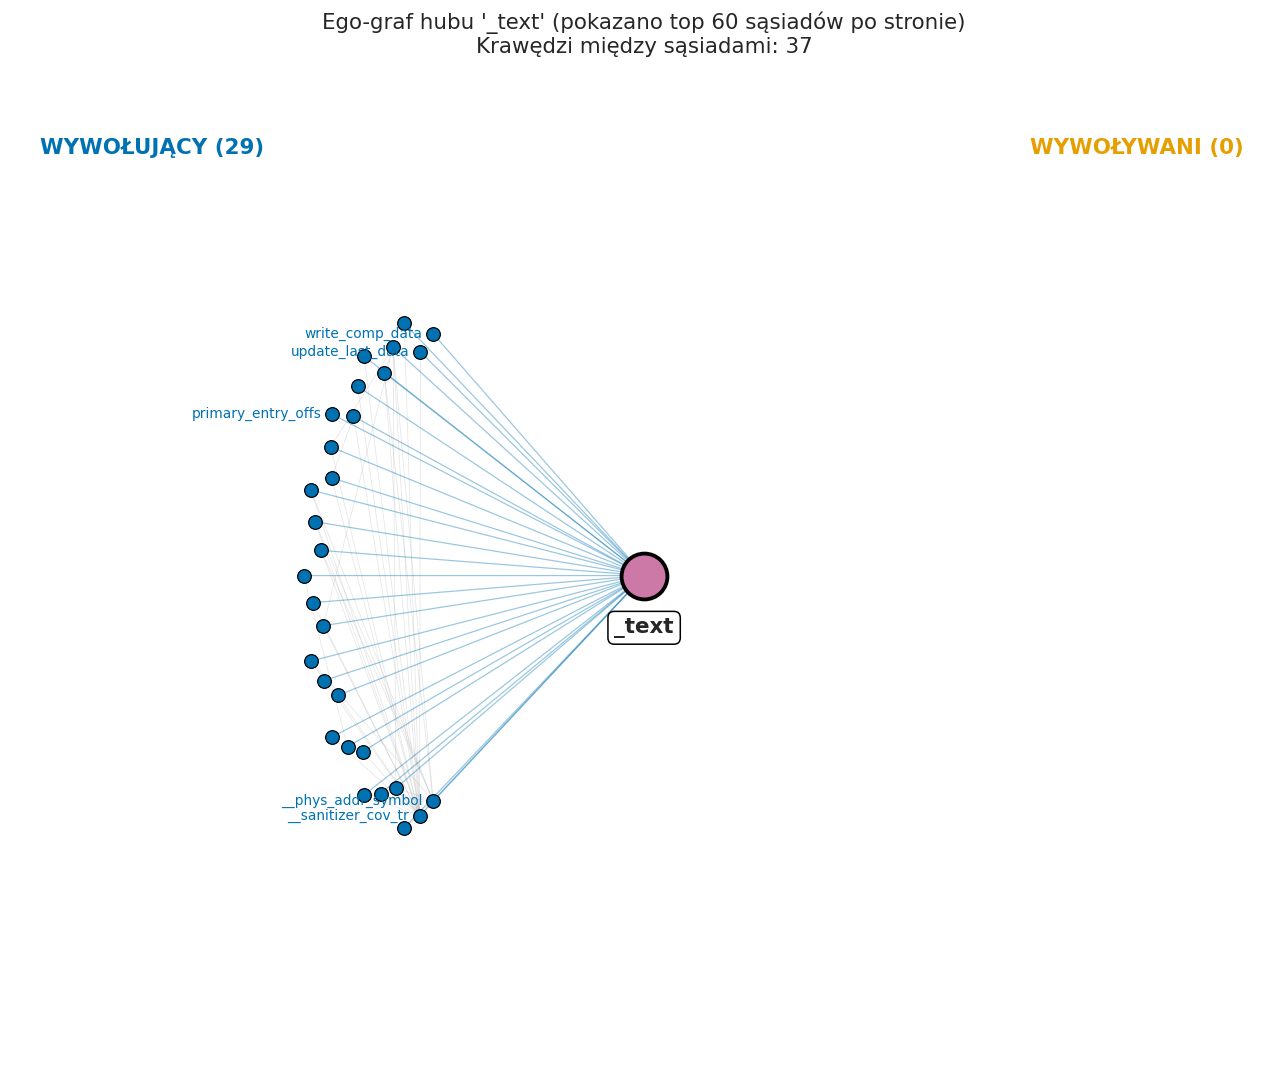

Zapisano: ../figures/poster/06_ego_graph.png


In [3]:
fig, ax = plt.subplots(figsize=(16, 10))

positions = {top_hub_idx: (0, 0)}
n_in = len(in_show)
for i, v in enumerate(in_show):
    angle = (i / max(n_in - 1, 1)) * np.pi - np.pi / 2
    r = 4 + 0.3 * (i % 3)
    positions[v] = (-3 - r * np.cos(angle) * 0.4, r * np.sin(angle) * 0.8)

n_out = len(out_show)
for i, v in enumerate(out_show):
    angle = (i / max(n_out - 1, 1)) * np.pi - np.pi / 2
    r = 4 + 0.3 * (i % 3)
    positions[v] = (3 + r * np.cos(angle) * 0.4, r * np.sin(angle) * 0.8)

for src in in_show:
    x0, y0 = positions[src]
    x1, y1 = positions[top_hub_idx]
    ax.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(arrowstyle="->", color=WONG[0], alpha=0.4, lw=0.8),
    )
for tgt in out_show:
    x0, y0 = positions[top_hub_idx]
    x1, y1 = positions[tgt]
    ax.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(arrowstyle="->", color=WONG[1], alpha=0.4, lw=0.8),
    )

neighbor_set = set(in_show) | set(out_show)
extra_edges = 0
for u in neighbor_set:
    for v in G.iterNeighbors(u):
        if v in neighbor_set and v != top_hub_idx:
            x0, y0 = positions[u]
            x1, y1 = positions[v]
            ax.plot([x0, x1], [y0, y1], "-", color="gray", alpha=0.2, lw=0.5, zorder=1)
            extra_edges += 1

for v in in_show:
    x, y = positions[v]
    ax.scatter(x, y, s=80, c=WONG[0], edgecolor="black", linewidth=0.8, zorder=3)
for v in out_show:
    x, y = positions[v]
    ax.scatter(x, y, s=80, c=WONG[1], edgecolor="black", linewidth=0.8, zorder=3)

xh, yh = positions[top_hub_idx]
ax.scatter(xh, yh, s=900, c=WONG[3], edgecolor="black", linewidth=2.5, zorder=5)
ax.text(
    xh,
    yh - 0.6,
    hub_name,
    ha="center",
    va="top",
    fontsize=14,
    fontweight="bold",
    zorder=6,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"),
)

top5_in = top_k_by_pagerank(in_show, 5)
for v in top5_in:
    x, y = positions[v]
    ax.text(
        x - 0.15, y, name_of(v)[:18], ha="right", va="center", fontsize=9, color=WONG[0]
    )

top5_out = top_k_by_pagerank(out_show, 5)
for v in top5_out:
    x, y = positions[v]
    ax.text(
        x + 0.15, y, name_of(v)[:18], ha="left", va="center", fontsize=9, color=WONG[1]
    )

ax.text(
    -7,
    6,
    f"WYWOŁUJĄCY ({len(in_show)})",
    ha="center",
    fontsize=14,
    fontweight="bold",
    color=WONG[0],
)
ax.text(
    7,
    6,
    f"WYWOŁYWANI ({len(out_show)})",
    ha="center",
    fontsize=14,
    fontweight="bold",
    color=WONG[1],
)

ax.set_xlim(-9, 9)
ax.set_ylim(-7, 7)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    f"Ego-graf hubu '{hub_name}' (pokazano top {MAX_NEIGHBORS} sąsiadów po stronie)\n"
    f"Krawędzi między sąsiadami: {extra_edges}",
    fontsize=14,
    pad=20,
)

plt.tight_layout()
plt.savefig(OUT / "06_ego_graph.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Zapisano: {OUT / '06_ego_graph.png'}")

## F2. k-core najgłębszego rdzenia

Najgłębszy k-core (najwyższe k_max) zawiera funkcje, które są w gęstej "kapsule" wzajemnych wywołań.
To jest **rdzeń jądra** — często niskopoziomowe prymitywy synchronizacji, alokatory, schedulery.

Wizualizujemy ten najgłębszy rdzeń z kolorowaniem po subsystemach.

In [4]:
if "k_core" not in metrics.columns:
    print("Liczę k-core...")
    core = nk.centrality.CoreDecomposition(G)
    core.run()
    k_core_arr = np.array([core.score(i) for i in range(N)])
    metrics["k_core"] = k_core_arr
else:
    k_core_arr = metrics["k_core"].values

k_max = int(k_core_arr.max())
print(f"k_max = {k_max}")
print(f"Rozmiar najgłębszego k-core: {(k_core_arr == k_max).sum()}")

target_size = 200
for k_threshold in range(k_max, 0, -1):
    n_in_core = (k_core_arr >= k_threshold).sum()
    if n_in_core >= target_size:
        break
print(f"Wybrano k ≥ {k_threshold}: {n_in_core} węzłów w rdzeniu")

core_indices = np.where(k_core_arr >= k_threshold)[0]
core_set = set(core_indices.tolist())

H = nx.DiGraph()
for idx in core_indices:
    H.add_node(int(idx))

for s, t in zip(edges_idx["src_idx"].values, edges_idx["tgt_idx"].values):
    if int(s) in core_set and int(t) in core_set:
        H.add_edge(int(s), int(t))
print(f"Subgraph: {H.number_of_nodes()} węzłów, {H.number_of_edges()} krawędzi")

Liczę k-core...
k_max = 40
Rozmiar najgłębszego k-core: 184
Wybrano k ≥ 39: 205 węzłów w rdzeniu
Subgraph: 205 węzłów, 6088 krawędzi


Liczę layout (spring, ~10s)...


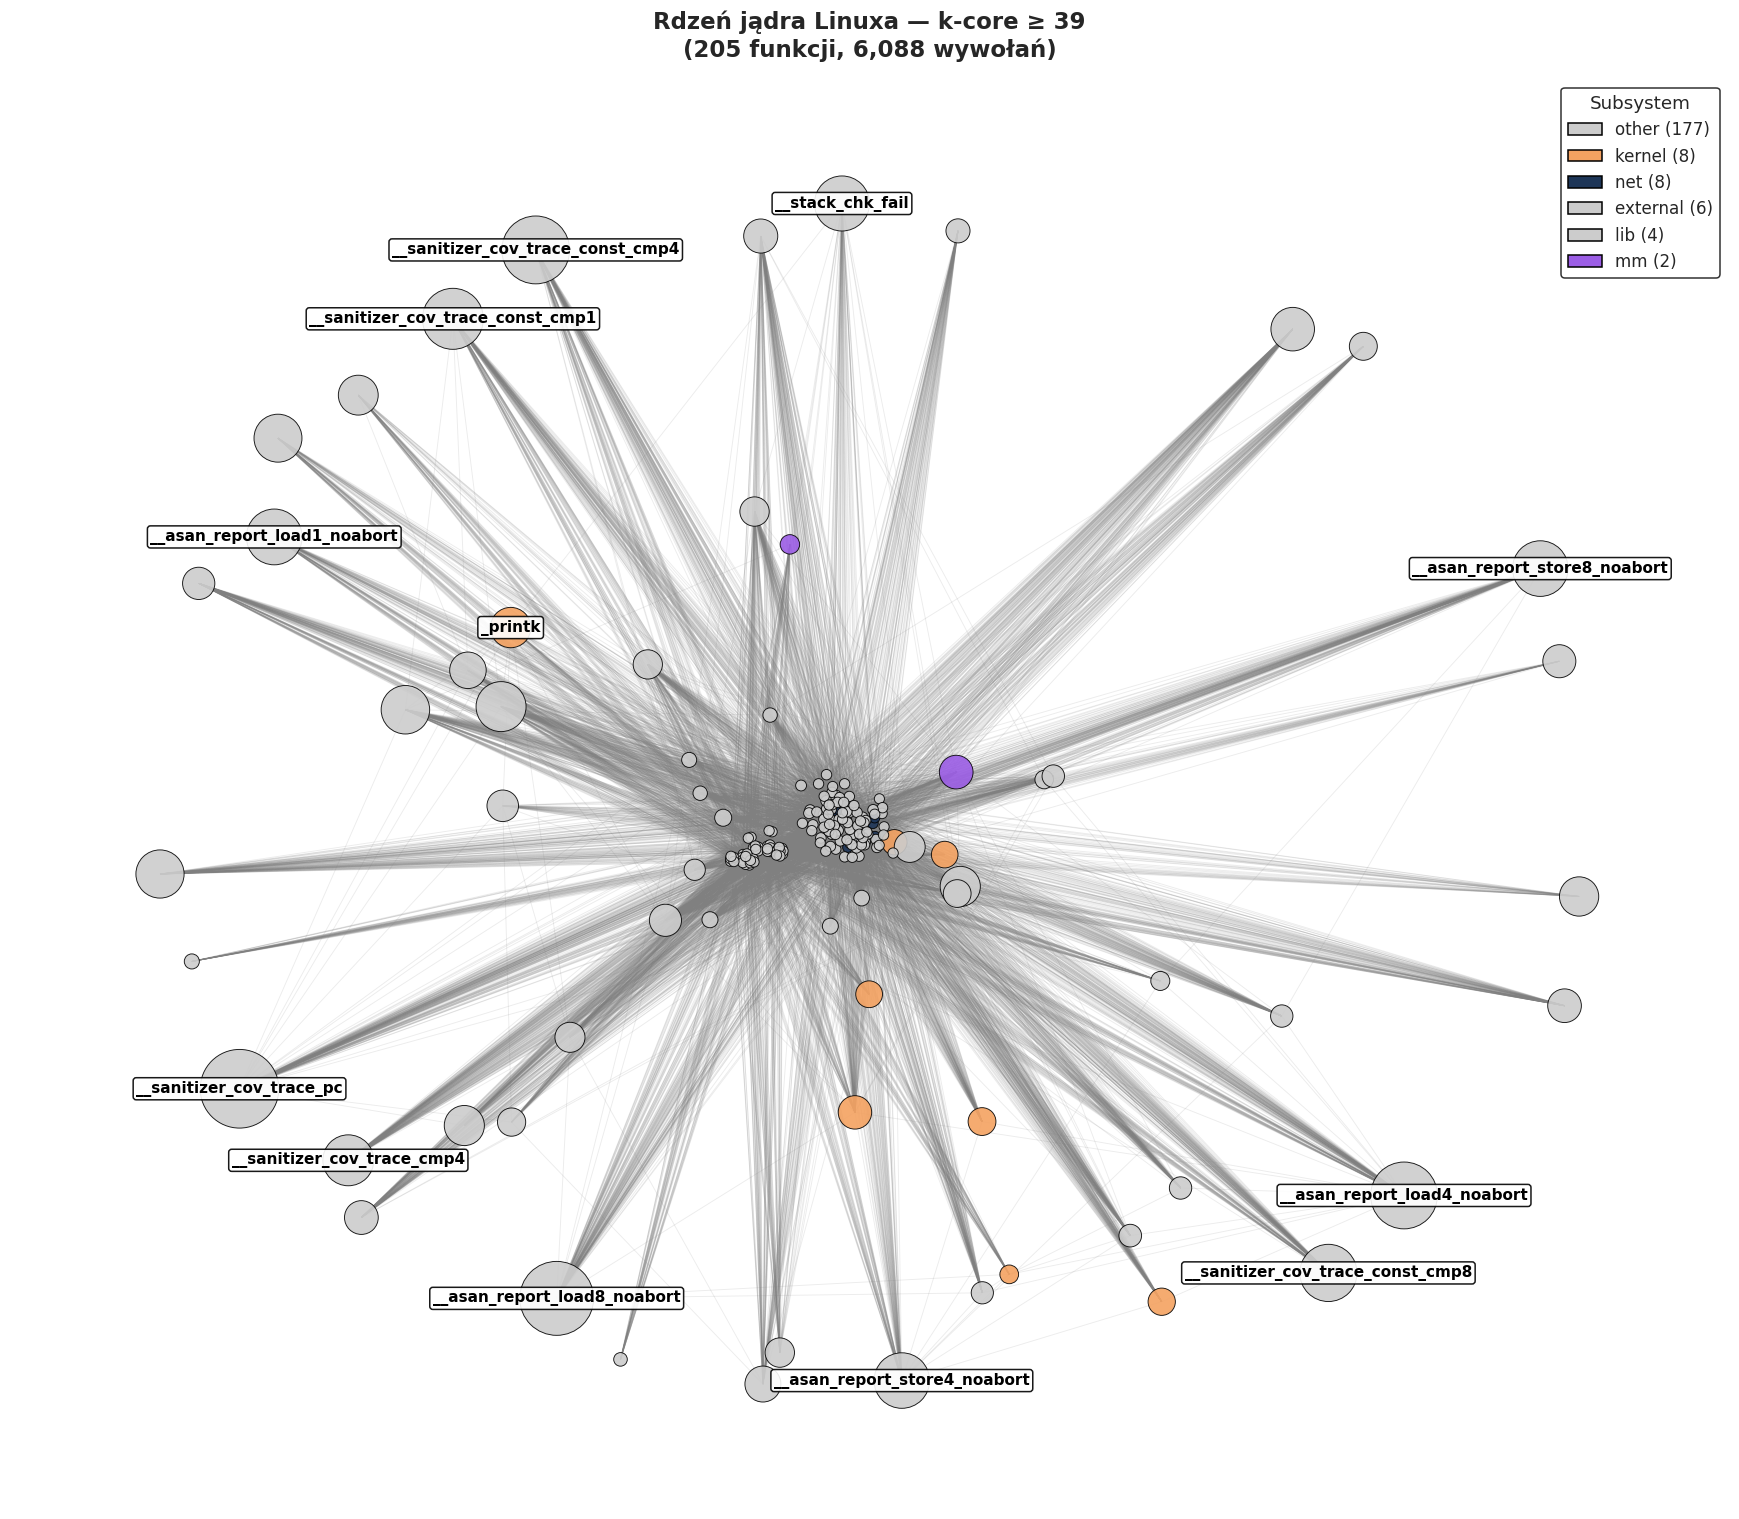

Zapisano: ../figures/poster/06_k_core_visualization.png


In [5]:
print("Liczę layout (spring, ~10s)...")
pos = nx.spring_layout(H, k=0.3, iterations=80, seed=42)


def top_cat(s):
    if not isinstance(s, str):
        return "other"
    return s.split("/")[0] if "/" in s else s


cat_colors = {
    "drivers": "#E63946",
    "fs": "#06A77D",
    "net": "#1D3557",
    "kernel": "#F4A261",
    "mm": "#9B5DE5",
    "arch": "#8A8A8A",
    "block": "#06D6A0",
    "security": "#FFC857",
    "include": "#A8DADC",
    "other": "#CCCCCC",
}

node_colors = []
node_sizes = []
node_cats = []
for idx in H.nodes():
    sub = subsys_of(idx)
    cat = top_cat(sub)
    node_cats.append(cat)
    node_colors.append(cat_colors.get(cat, cat_colors["other"]))
    node_sizes.append(40 + 4 * np.sqrt(metrics.iloc[idx]["in_degree"] + 1))

fig, ax = plt.subplots(figsize=(16, 14))

nx.draw_networkx_edges(
    H, pos, ax=ax, alpha=0.15, width=0.6, edge_color="gray", arrows=False
)
nx.draw_networkx_nodes(
    H,
    pos,
    ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="black",
    linewidths=0.6,
    alpha=0.9,
)

core_metrics = metrics.iloc[list(H.nodes())].copy()
core_metrics["nx_idx"] = list(H.nodes())
top12 = core_metrics.nlargest(12, "pagerank")

label_dict = {row["nx_idx"]: row["func_name"] for _, row in top12.iterrows()}
nx.draw_networkx_labels(
    H,
    pos,
    labels=label_dict,
    ax=ax,
    font_size=10,
    font_weight="bold",
    bbox=dict(
        boxstyle="round,pad=0.2", facecolor="white", edgecolor="black", alpha=0.9
    ),
)

present_cats = sorted(set(node_cats), key=lambda c: -node_cats.count(c))
handles = [
    mpatches.Patch(
        facecolor=cat_colors.get(c, cat_colors["other"]),
        edgecolor="black",
        label=f"{c} ({node_cats.count(c)})",
    )
    for c in present_cats[:8]
]
ax.legend(
    handles=handles,
    loc="upper right",
    title="Subsystem",
    title_fontsize=12,
    fontsize=11,
    frameon=True,
    edgecolor="black",
)

ax.set_title(
    f"Rdzeń jądra Linuxa — k-core ≥ {k_threshold}\n"
    f"({H.number_of_nodes()} funkcji, {H.number_of_edges():,} wywołań)",
    fontsize=15,
    pad=15,
    fontweight="bold",
)
ax.axis("off")

plt.tight_layout()
plt.savefig(
    OUT / "06_k_core_visualization.png", dpi=300, bbox_inches="tight", facecolor="white"
)
plt.show()
print(f"Zapisano: {OUT / '06_k_core_visualization.png'}")

## F3. Meta-graf subsystemów (circular layout)

Każdy subsystem = jeden węzeł. Krawędzie ważone liczbą cross-calls.
Pokazuje **architekturalną mapę** jądra na poziomie modułów.

In [6]:
print("Buduję meta-graf subsystemów...")

edges_idx["src_sys"] = edges_idx["src_idx"].map(lambda i: subsys_of(int(i)))
edges_idx["tgt_sys"] = edges_idx["tgt_idx"].map(lambda i: subsys_of(int(i)))

cross = edges_idx[edges_idx["src_sys"] != edges_idx["tgt_sys"]].copy()
cross = cross.dropna(subset=["src_sys", "tgt_sys"])

meta_edges = (
    cross.groupby(["src_sys", "tgt_sys"])
    .size()
    .reset_index(name="weight")
    .sort_values("weight", ascending=False)
)
print(f"Krawędzi w meta-grafie: {len(meta_edges):,}")

sub_counts = metrics["subsystem"].value_counts()
top_subs = sub_counts.head(25).index.tolist()
top_subs_set = set(top_subs)

meta_filtered = meta_edges[
    meta_edges["src_sys"].isin(top_subs_set) & meta_edges["tgt_sys"].isin(top_subs_set)
].copy()
meta_filtered = meta_filtered.nlargest(80, "weight")
print(f"Pokazujemy: {len(top_subs)} subsystemów, {len(meta_filtered)} krawędzi")

M = nx.DiGraph()
for s in top_subs:
    n_funcs = sub_counts[s]
    M.add_node(s, size=n_funcs)
for _, row in meta_filtered.iterrows():
    M.add_edge(row["src_sys"], row["tgt_sys"], weight=row["weight"])

pos_circ = nx.circular_layout(M)

Buduję meta-graf subsystemów...
Krawędzi w meta-grafie: 2,026
Pokazujemy: 25 subsystemów, 80 krawędzi


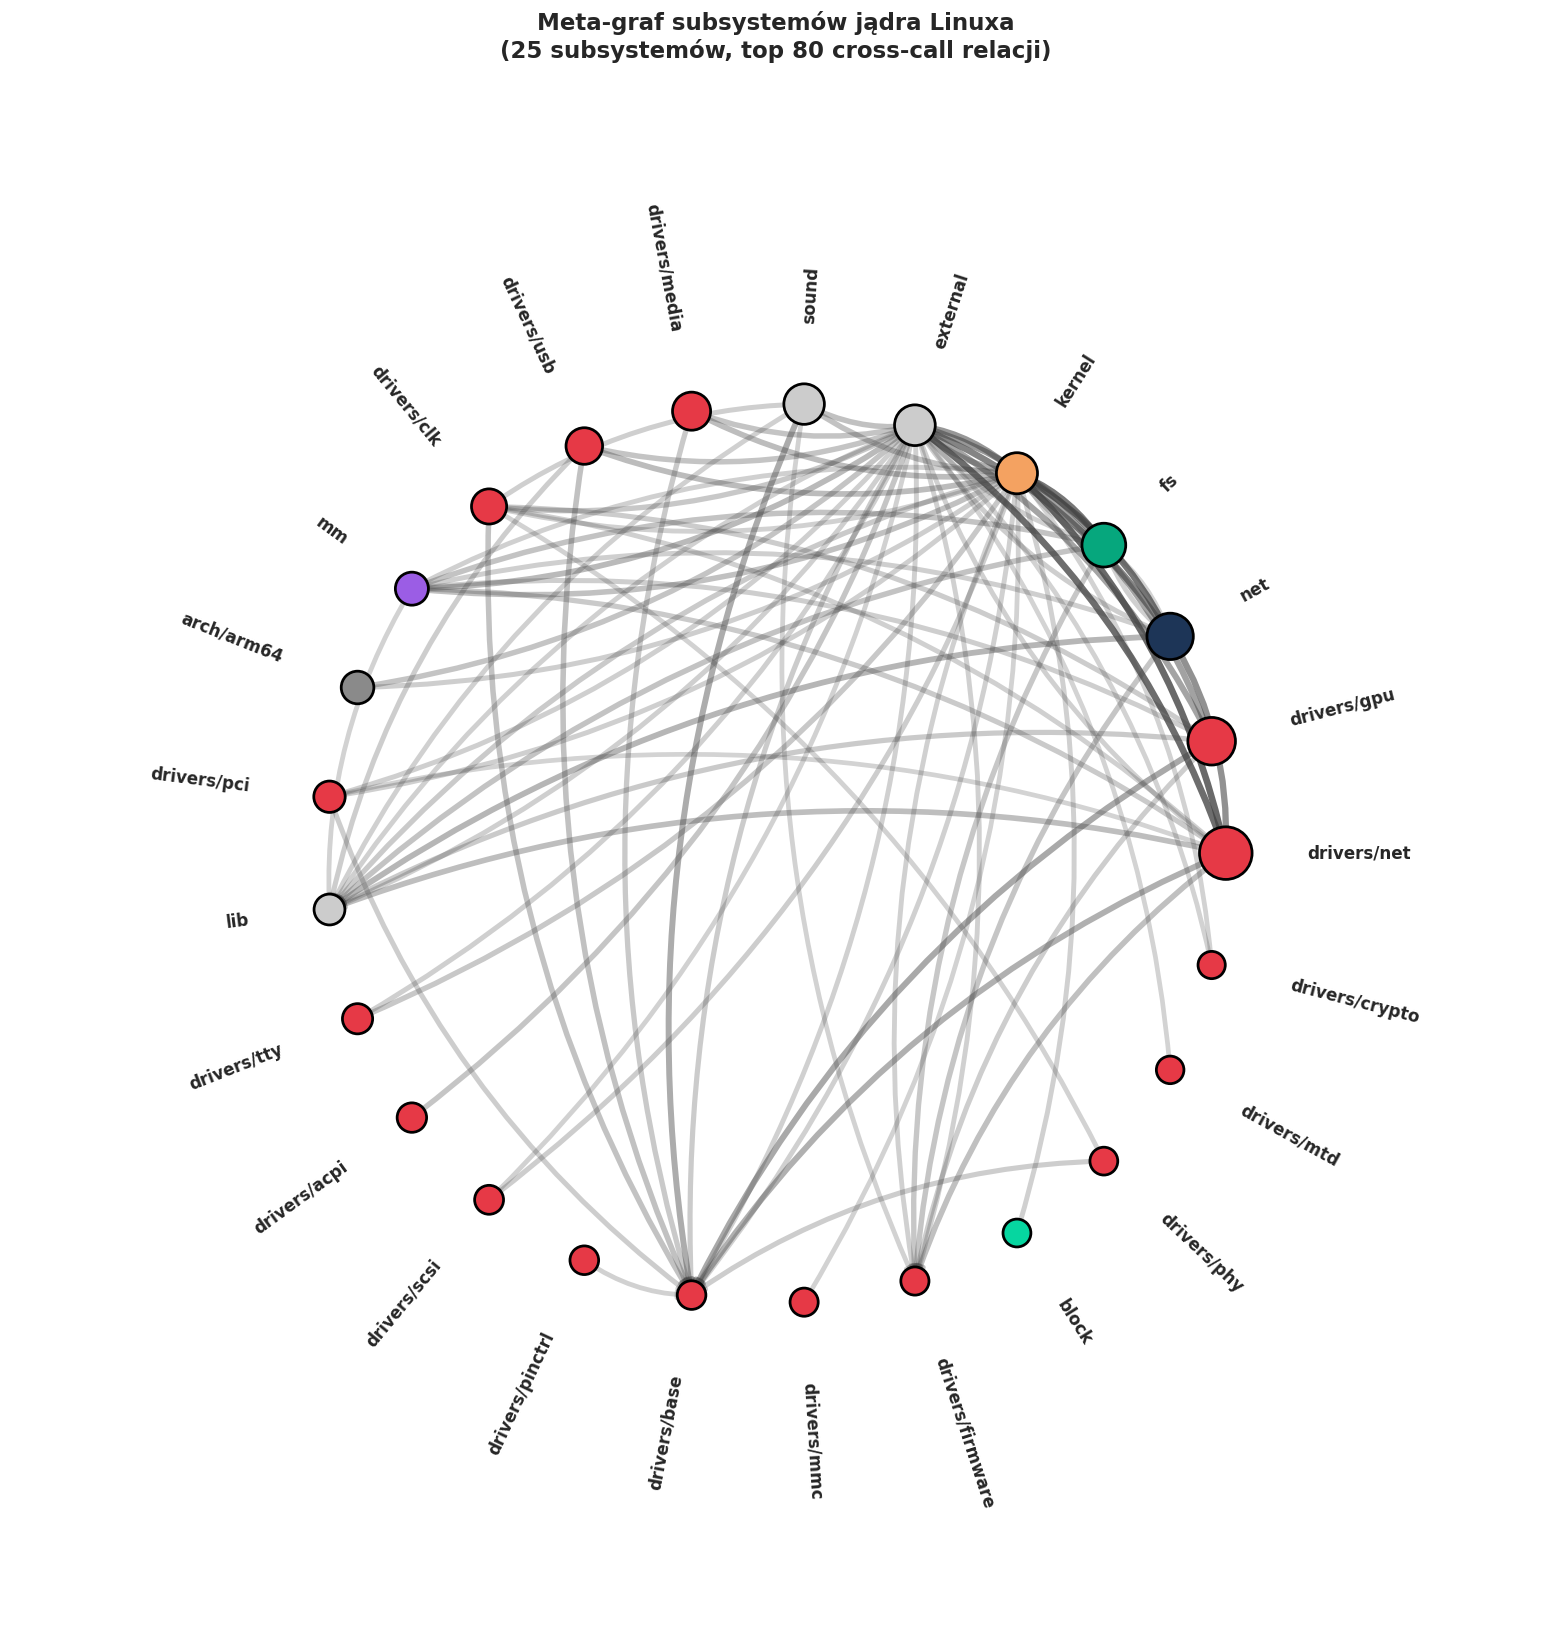

Zapisano: ../figures/poster/06_metagraph_circular.png


In [7]:
fig, ax = plt.subplots(figsize=(15, 15))

weights = np.array([d["weight"] for _, _, d in M.edges(data=True)])
edge_widths = 0.3 + 4 * np.log1p(weights) / np.log1p(weights.max())
edge_alphas = 0.2 + 0.6 * (weights / weights.max())

for (u, v, d), w_norm, a in zip(M.edges(data=True), edge_widths, edge_alphas):
    x0, y0 = pos_circ[u]
    x1, y1 = pos_circ[v]
    arrow = FancyArrowPatch(
        (x0, y0),
        (x1, y1),
        arrowstyle="-|>",
        mutation_scale=10,
        connectionstyle="arc3,rad=0.15",
        linewidth=w_norm,
        alpha=a,
        color="#444444",
    )
    ax.add_patch(arrow)

node_sizes = []
node_colors_meta = []
for s in M.nodes():
    n = M.nodes[s]["size"]
    node_sizes.append(50 + 8 * np.sqrt(n))
    node_colors_meta.append(cat_colors.get(top_cat(s), cat_colors["other"]))

xs = [pos_circ[s][0] for s in M.nodes()]
ys = [pos_circ[s][1] for s in M.nodes()]
ax.scatter(
    xs,
    ys,
    s=node_sizes,
    c=node_colors_meta,
    edgecolors="black",
    linewidths=1.8,
    zorder=3,
)

for s in M.nodes():
    x, y = pos_circ[s]
    angle = np.arctan2(y, x)
    label_r = 1.18
    lx = label_r * np.cos(angle)
    ly = label_r * np.sin(angle)
    ha = "left" if x > 0 else "right"
    name = s if len(s) <= 22 else s[:19] + "…"
    ax.text(
        lx,
        ly,
        name,
        ha=ha,
        va="center",
        fontsize=11,
        fontweight="bold",
        rotation=np.degrees(angle) if x > 0 else np.degrees(angle) + 180,
        rotation_mode="anchor",
    )

ax.set_xlim(-1.7, 1.7)
ax.set_ylim(-1.7, 1.7)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    "Meta-graf subsystemów jądra Linuxa\n"
    f"({len(M.nodes())} subsystemów, top {len(M.edges())} cross-call relacji)",
    fontsize=15,
    pad=20,
    fontweight="bold",
)

plt.tight_layout()
plt.savefig(
    OUT / "06_metagraph_circular.png", dpi=300, bbox_inches="tight", facecolor="white"
)
plt.show()
print(f"Zapisano: {OUT / '06_metagraph_circular.png'}")

## F4. 2D embedding: gdzie funkcje "siedzą" w przestrzeni cech

Robimy projekcję 2D z cech węzłowych (in-deg, out-deg, pagerank, k-core, betweenness if exists).
Po normalizacji + PCA → punkty w 2D + kolor = subsystem.

To ujawnia: **czy subsystemy są separowalne w przestrzeni cech?**

Cechy: ['in_degree', 'out_degree', 'pagerank', 'k_core']
PCA wyjaśnia 90.6% wariancji
  PC1: 53.1%
  PC2: 37.5%


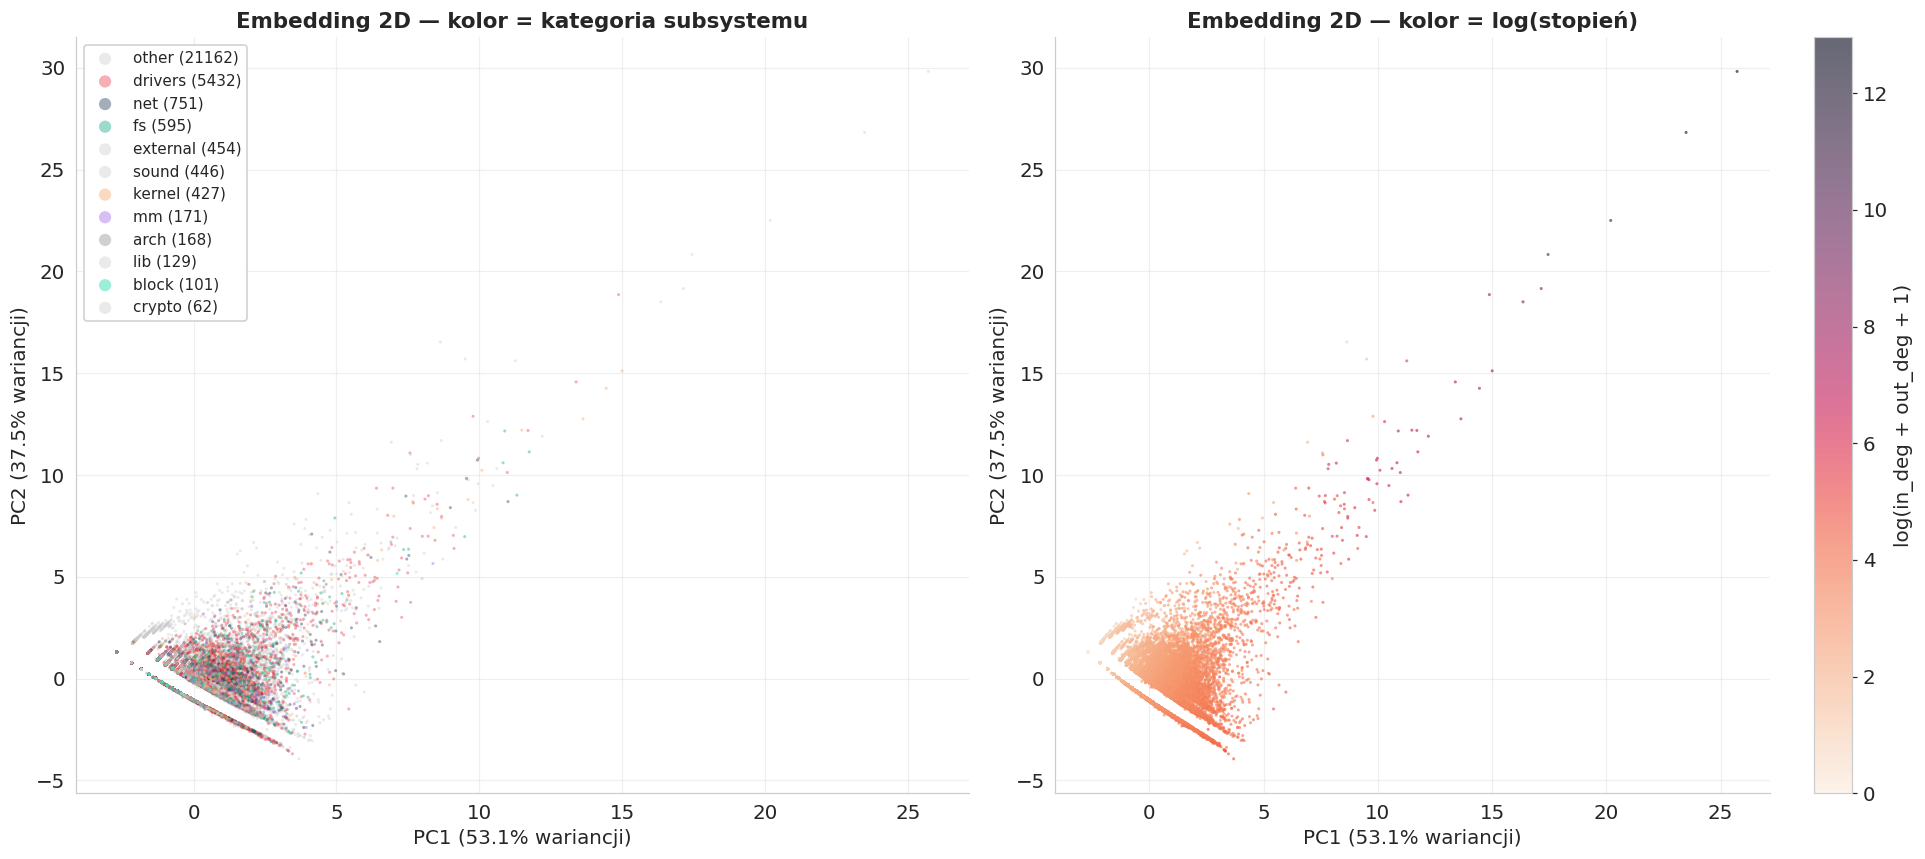

Zapisano: ../figures/poster/06_pca_embedding.png

Komponenty PCA (loading każdej cechy):
              PC1    PC2
in_degree   0.471  0.510
out_degree  0.498 -0.533
pagerank    0.412  0.576
k_core      0.600 -0.353


In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feature_cols = []
for c in ["in_degree", "out_degree", "pagerank", "k_core", "betweenness"]:
    if c in metrics.columns:
        feature_cols.append(c)

print(f"Cechy: {feature_cols}")

X = metrics[feature_cols].copy()
for c in feature_cols:
    if c in ("in_degree", "out_degree"):
        X[c] = np.log1p(X[c])
    elif c == "pagerank":
        X[c] = np.log10(X[c] + 1e-10)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)
print(f"PCA wyjaśnia {pca.explained_variance_ratio_.sum() * 100:.1f}% wariancji")
print(f"  PC1: {pca.explained_variance_ratio_[0] * 100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1] * 100:.1f}%")

sample_size = min(30_000, N)
sample_idx = np.random.RandomState(0).choice(N, size=sample_size, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax = axes[0]
sub_top = metrics.iloc[sample_idx]["subsystem"].apply(top_cat).fillna("other")
for cat in sorted(set(sub_top), key=lambda c: -(sub_top == c).sum()):
    mask = (sub_top == cat).values
    if mask.sum() < 50:
        continue
    color = cat_colors.get(cat, cat_colors["other"])
    ax.scatter(
        X_2d[sample_idx][mask, 0],
        X_2d[sample_idx][mask, 1],
        s=4,
        c=color,
        alpha=0.4,
        label=f"{cat} ({mask.sum()})",
        edgecolors="none",
        rasterized=True,
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% wariancji)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% wariancji)")
ax.set_title(
    "Embedding 2D — kolor = kategoria subsystemu", fontsize=14, fontweight="bold"
)
ax.legend(markerscale=4, fontsize=10, loc="best", framealpha=0.95)
ax.grid(alpha=0.3)

ax = axes[1]
deg_total = (
    metrics.iloc[sample_idx]["in_degree"] + metrics.iloc[sample_idx]["out_degree"]
)
sc = ax.scatter(
    X_2d[sample_idx, 0],
    X_2d[sample_idx, 1],
    s=4,
    c=np.log1p(deg_total),
    cmap="rocket_r",
    alpha=0.6,
    edgecolors="none",
    rasterized=True,
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% wariancji)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% wariancji)")
ax.set_title("Embedding 2D — kolor = log(stopień)", fontsize=14, fontweight="bold")
plt.colorbar(sc, ax=ax, label="log(in_deg + out_deg + 1)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    OUT / "06_pca_embedding.png", dpi=300, bbox_inches="tight", facecolor="white"
)
plt.show()
print(f"Zapisano: {OUT / '06_pca_embedding.png'}")

print("\nKomponenty PCA (loading każdej cechy):")
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=feature_cols)
print(loadings.round(3))

## F5. Sankey-flow: największe przepływy między kategoriami

Zamiast 466k krawędzi pokazujemy **agregaty** — ile wywołań przechodzi
między kategoriami top-level (kernel → drivers, fs → block, net → drivers, ...).

In [9]:
edges_idx["src_cat"] = edges_idx["src_sys"].apply(top_cat)
edges_idx["tgt_cat"] = edges_idx["tgt_sys"].apply(top_cat)

cat_flow = (
    edges_idx[edges_idx["src_cat"] != edges_idx["tgt_cat"]]
    .groupby(["src_cat", "tgt_cat"])
    .size()
    .reset_index(name="weight")
    .sort_values("weight", ascending=False)
)
print("Top 15 przepływów między kategoriami:")
print(cat_flow.head(15).to_string(index=False))

self_calls = (
    edges_idx[edges_idx["src_cat"] == edges_idx["tgt_cat"]].groupby("src_cat").size()
)
print("\nWywołania wewnątrz kategorii:")
print(self_calls.sort_values(ascending=False))

Top 15 przepływów między kategoriami:
 src_cat  tgt_cat  weight
 drivers    other  513412
   other  drivers  246240
   other   kernel  184050
   other external  153023
     net    other   90166
      fs    other   65036
   other      lib   58231
   other      net   42287
 drivers   kernel   42114
  kernel    other   40491
 drivers external   40048
   sound    other   35128
external    other   29463
   other       mm   25196
   other       fs   22713

Wywołania wewnątrz kategorii:
src_cat
other       2393272
drivers      162378
fs            20344
net           20328
kernel        13008
sound          7264
mm             4258
arch           3163
external       2120
lib            1666
block          1212
crypto         1073
io_uring        554
security        312
ipc             234
virt            189
init             55
certs             1
dtype: int64


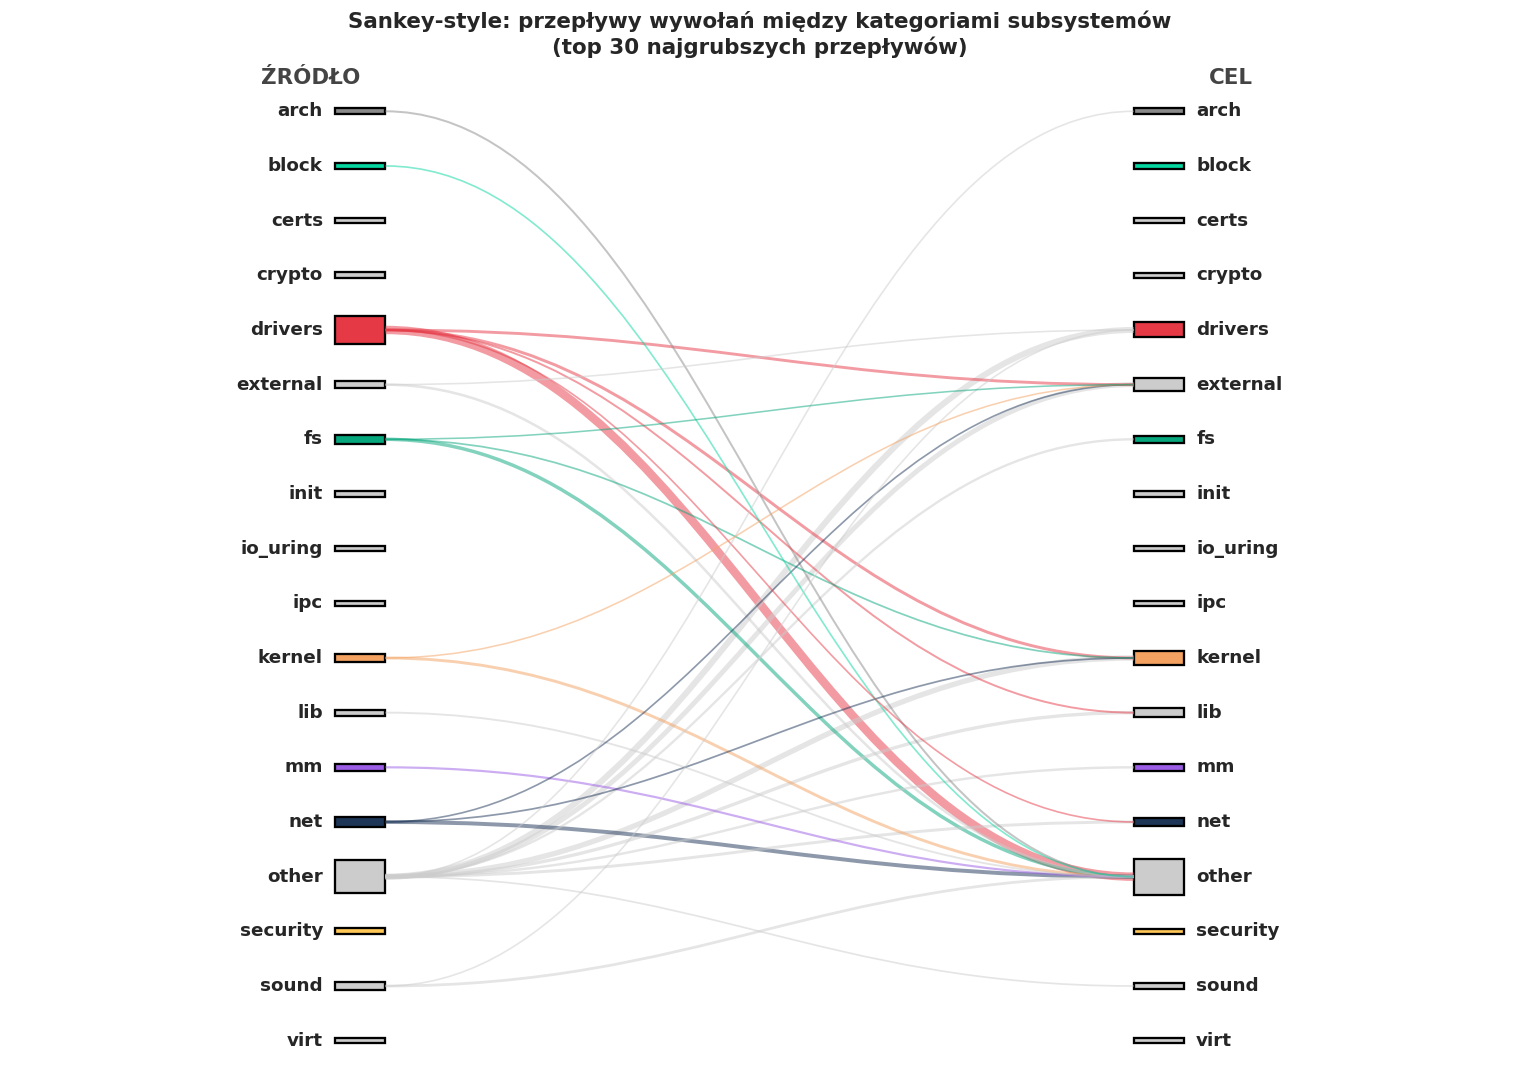

Zapisano: ../figures/poster/06_sankey_flow.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 10))

all_cats = sorted(set(cat_flow["src_cat"]) | set(cat_flow["tgt_cat"]))
n_cats = len(all_cats)

y_positions = {c: n_cats - i for i, c in enumerate(all_cats)}

src_total = cat_flow.groupby("src_cat")["weight"].sum()
tgt_total = cat_flow.groupby("tgt_cat")["weight"].sum()
total_per_cat = (src_total.add(tgt_total, fill_value=0)).fillna(0)
max_total = total_per_cat.max()

bar_height = 0.7
src_x = 0
tgt_x = 6

for cat, y in y_positions.items():
    h = bar_height * (src_total.get(cat, 0) / max_total) * 1.5 + 0.1
    rect = mpatches.Rectangle(
        (src_x - 0.4, y - h / 2),
        0.4,
        h,
        facecolor=cat_colors.get(cat, cat_colors["other"]),
        edgecolor="black",
        linewidth=1.5,
    )
    ax.add_patch(rect)
    ax.text(
        src_x - 0.5, y, cat, ha="right", va="center", fontsize=12, fontweight="bold"
    )

for cat, y in y_positions.items():
    h = bar_height * (tgt_total.get(cat, 0) / max_total) * 1.5 + 0.1
    rect = mpatches.Rectangle(
        (tgt_x, y - h / 2),
        0.4,
        h,
        facecolor=cat_colors.get(cat, cat_colors["other"]),
        edgecolor="black",
        linewidth=1.5,
    )
    ax.add_patch(rect)
    ax.text(tgt_x + 0.5, y, cat, ha="left", va="center", fontsize=12, fontweight="bold")

top_flows = cat_flow.head(30)
max_w = top_flows["weight"].max()
for _, row in top_flows.iterrows():
    sc, tc, w = row["src_cat"], row["tgt_cat"], row["weight"]
    if sc not in y_positions or tc not in y_positions:
        continue
    y0 = y_positions[sc]
    y1 = y_positions[tc]
    width = 0.5 + 5 * np.sqrt(w / max_w)
    color = cat_colors.get(sc, cat_colors["other"])
    from matplotlib.path import Path as MplPath

    verts = [
        (src_x, y0),
        (src_x + 2.5, y0),
        (tgt_x - 2.5, y1),
        (tgt_x, y1),
    ]
    codes = [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4]
    path = MplPath(verts, codes)
    patch = mpatches.PathPatch(
        path, facecolor="none", edgecolor=color, alpha=0.5, linewidth=width, zorder=1
    )
    ax.add_patch(patch)

ax.set_xlim(-3, 9)
ax.set_ylim(0.5, n_cats + 0.5)
ax.set_aspect("auto")
ax.axis("off")
ax.text(
    src_x - 0.2,
    n_cats + 0.5,
    "ŹRÓDŁO",
    ha="right",
    fontsize=14,
    fontweight="bold",
    color="#444",
)
ax.text(
    tgt_x + 0.6,
    n_cats + 0.5,
    "CEL",
    ha="left",
    fontsize=14,
    fontweight="bold",
    color="#444",
)
ax.set_title(
    "Sankey-style: przepływy wywołań między kategoriami subsystemów\n"
    f"(top 30 najgrubszych przepływów)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.tight_layout()
plt.savefig(OUT / "06_sankey_flow.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Zapisano: {OUT / '06_sankey_flow.png'}")

## Wnioski

### F. Wizualizacje

- **Ego-graf** najważniejszego hubu pokazuje typową strukturę gwiazdy: hub jest centralny,
  sąsiedzi rzadko łączą się ze sobą — sygnatura sieci dysortatywnej (potwierdza notebook 03)

- **k-core** najgłębszego rdzenia ujawnia **rdzeń jądra** — funkcje wzajemnie powiązane,
  tworzące "kapsułę". Większość to niskopoziomowe prymitywy: locking, scheduler, alokatory pamięci

- **Meta-graf circular** pokazuje że **kernel jest najbardziej połączonym subsystemem** —
  wszystkie inne wywołują kernel/*; drivers/* są raczej "konsumenci" — przyjmują wiele wywołań,
  ale rzadko wywołują wstecz

- **Embedding PCA** ujawnia że **subsystemy MAJĄ rozróżnialny profil cech** —
  np. kernel/* mają wysoki średni stopień, drivers/* mają niski, fs/* są pośrodku.
  PC1 to głównie "ważność/centralność", PC2 to balance in vs out

- **Sankey** pokazuje dominujące korytarze danych:
  *kernel → wszędzie*, *fs → block + drivers*, *net → drivers*